# AI-Generated Citations: A Cross-Model Study of Citation Generation

## 1. Introduction

Citations lend credibility to written work by anchoring claims in verifiable sources (Subramanian et al., 2025). For consultancies, R & D teams and publishers, accurate references are business‑critical: they win bids, secure patents and satisfy regulators. Yet booming research output and the rise of imperfect AI tools make trustworthy citation harder than ever. Large language models (LLMs) frequently invent or distort references, creating legal and reputational risk (Walters & Wilder, 2023). Unchecked “AI citation inflation” could erode confidence across scholarly communication (Tennant et al., 2024).

Current workflows reveal four systemic flaws:
1. Fluency over factuality — Models optimise for eloquence, not accuracy, and provide no built‑in validation (Walters & Wilder, 2023).
2. No quality benchmarks — Without relevance or recency scoring, organisations cannot compare tools objectively (Tennant et al., 2024).
3. Manual inefficiency — Human compilation is slow and inconsistent for lengthy technical documents.
4. Hallucination & mis‑attribution — LLMs generate plausible but non‑existent references, lacking DOI or metadata checks (Ji et al., 2023).

To address these gaps, we benchmark three premium LLM services—GPT‑4.1‑mini, Gemini and DeepSeek—against two licence‑free baselines—KeyBERT and Latent Dirichlet Allocation (LDA). Using ten consulting‑style PDFs, each pipeline:
* extracts three to five keywords,
* retrieves candidate papers from arXiv, and
* ranks results by MiniLM semantic similarity.

This open, head‑to‑head assessment provides cost‑to‑quality evidence that helps decision‑makers embed AI citation tools in mission‑critical workflows while minimising the liabilities of fabricated references



## 2. Methodology

All experiments were carried out in Python. We first used pdfplumber to pull raw text from each PDF. Those texts - and every candidate paper we later downloaded - were converted into numeric embeddings with the sentence-transformers library (specifically the all‑MiniLM‑L6‑v2 model), while torch handled the underlying tensor operations and cosine-similarity calculations. The requests package managed all HTTP calls to the arXiv API, fetching titles and abstracts, and pandas organised the resulting data frames, allowing us to filter, rank and export the citation lists.

### 2.1 Data Collection


A sample of ten PDF briefs (150–300 words each) replicate real consulting scenarios—e.g., employee retention, fraud detection, multi‑channel marketing. Their business‑focused language provides a consistent testbed for keyword extractors.




### 2.2 Tools Evaluated

Five pipelines span traditional and generative methods:

| **Type**           | **Tool**              | **Extraction Method**                         |
|--------------------|-----------------------|-----------------------------------------------|
| Embedding Baseline | `KeyBERT`             | BERT embeddings + cosine distance             |
| Topic Baseline     | `LDA`                 | Probabilistic topic modeling                  |
| Prompted LLMs      | `GPT-4.1-mini`        | Prompt: "Extract 3–5 keywords..."             |
|                    | `Gemini`              | Prompt: "Extract 3–5 keywords..."             |
|                    | `DeepSeek`            | Prompt: "Extract 3–5 keywords..."             |

---
Each model independently processes the same ten briefs and returns three to five search terms.


# MAIN CODE

## Install and Import libraries

In [ ]:
!pip install -q pdfplumber sentence-transformers datasets transformers faiss-cpu scikit-learn keybert google-generativeai openpyxl PyPDF2

import pdfplumber
import requests
from sentence_transformers import SentenceTransformer, util
from google.colab import files
import xml.etree.ElementTree as ET
import torch
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from keybert import KeyBERT
import os
import pandas as pd
from PyPDF2 import PdfReader
import google.generativeai as genai
from google.colab import userdata
from openai import OpenAI
import seaborn as sns
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.2/60.2 kB 355.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.

## API Key Setup

In [ ]:
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
DEEPSEEK_API = userdata.get("DEEPSEEK_API")
GEMINI_API_KEY = userdata.get("GEMINI_API")

## Upload PDF

In [ ]:
# Upload a file (works in environments like Google Colab)
# 'uploaded' will be a dictionary containing the uploaded file data
uploaded = files.upload()

# Extract the filename(s) of the uploaded file(s)
# 'uploaded.keys()' gives the filenames, converted to a list
pdf_path = list(uploaded.keys())

# 'pdf_path' now contains the path(s) of the uploaded PDF(s)
pdf_path

Saving Case-Eight.pdf to Case-Eight.pdf
Saving Case-Five.pdf to Case-Five.pdf
Saving Case-Four.pdf to Case-Four.pdf
Saving Case-Nine.pdf to Case-Nine.pdf
Saving Case-One.pdf to Case-One.pdf
Saving Case-Seven.pdf to Case-Seven.pdf
Saving Case-Six.pdf to Case-Six.pdf
Saving Case-Ten.pdf to Case-Ten.pdf
Saving Case-Three.pdf to Case-Three.pdf
Saving Case-Two.pdf to Case-Two.pdf


['Case-Eight.pdf',
 'Case-Five.pdf',
 'Case-Four.pdf',
 'Case-Nine.pdf',
 'Case-One.pdf',
 'Case-Seven.pdf',
 'Case-Six.pdf',
 'Case-Ten.pdf',
 'Case-Three.pdf',
 'Case-Two.pdf']

## Extract text

In [ ]:
def extract_text(pdf_path):
    """Extract and clean text from a PDF file.

    Args:
        pdf_path (str): Path to the PDF file to be processed.

    Returns:
        str: Cleaned text content of the PDF with normalized whitespace.
    """
    # Open the PDF file using pdfplumber
    with pdfplumber.open(pdf_path) as pdf:
        all_text = ""  # Initialize an empty string to store extracted text

        # Iterate through each page in the PDF
        for page in pdf.pages:
            # Extract text from the current page
            text = page.extract_text()

            # If text was extracted from the page, add it to the result
            if text:
                all_text += text + "\n"  # Add newline between pages

    # Return the cleaned text:
    # 1. .strip() removes leading/trailing whitespace
    # 2. re.sub replaces all whitespace sequences with single spaces
    return re.sub(r'\s+', ' ', all_text.strip())

## DEEPSEEK

In [ ]:
# 2. Deepseek generates query - Function to get research keywords from text using Deepseek API
def query_deepseek(api_key, user_input):
    """Generate academic search keywords using Deepseek API.

    Args:
        api_key (str): Deepseek API key for authentication
        user_input (str): Text content to analyze for keywords

    Returns:
        str: Numbered list of 3-5 academic keywords extracted from the text
    """
    # API endpoint configuration
    url = "https://api.deepseek.com/v1/chat/completions"
    headers = {"Authorization": f"Bearer {api_key}"}  # Authentication header

    # API request payload with system prompt and user input
    payload = {
        "model": "deepseek-chat",  # Using Deepseek's chat model
        "messages": [
            {
                "role": "system",
                "content": (
                    "You are an academic research assistant. "
                    "Given the text below, extract 3 to 5 concise academic search keywords "
                    "(not full queries) that best represent the core research topics or concepts in the text. "
                    "Return only the keywords as a numbered list."
                )
            },
            {"role": "user", "content": user_input}  # The text to analyze
        ],
        "temperature": 0  # For deterministic output
    }

    # Make API request and return the generated keywords
    response = requests.post(url, headers=headers, json=payload)
    return response.json()['choices'][0]['message']['content'].strip()

# 3️. arXiv look up - Function to search for academic papers on arXiv
def fetch_arxiv_papers(query, max_results=50):
    """Fetch relevant papers from arXiv based on search query.

    Args:
        query (str): Search terms to look up on arXiv
        max_results (int): Maximum number of papers to return

    Returns:
        list: Dictionary of papers with title, summary, and link
    """
    # Construct arXiv API query URL
    url = f"http://export.arxiv.org/api/query?search_query=all:{query}&start=0&max_results={max_results}"
    response = requests.get(url)  # Execute the API request

    # Parse XML response from arXiv
    root = ET.fromstring(response.content)
    papers = []

    # Extract paper information from each entry in the response
    for entry in root.findall('{http://www.w3.org/2005/Atom}entry'):
        title = entry.find('{http://www.w3.org/2005/Atom}title').text.strip()
        summary = entry.find('{http://www.w3.org/2005/Atom}summary').text.strip()
        link = entry.find('{http://www.w3.org/2005/Atom}id').text.strip()
        papers.append({'title': title, 'summary': summary, 'link': link})

    return papers

# 4️. Cosine similarity comparison - Function to display top matching papers
def show_top_matches(scores, papers, model_name, top_k=5):
    """Display and return the top matching papers based on similarity scores.

    Args:
        scores (torch.Tensor): Cosine similarity scores for papers
        papers (list): List of paper dictionaries
        model_name (str): Name of embedding model used
        top_k (int): Number of top results to return

    Returns:
        list: Processed results with title, score, summary and URL
    """
    print(f"\n🔍 Top {top_k} Matches for {model_name}:\n")
    top_results = torch.topk(scores, k=top_k)  # Get indices of top scores
    results = []

    # Process and display each top result
    for idx, score in zip(top_results.indices, top_results.values):
        paper = papers[int(idx)]
        print(f"📄 Title   : {paper['title']}")
        print(f"📈 Score   : {score.item():.4f}")  # Convert tensor to float
        print(f"📝 Summary : {paper['summary'][:300]}...\n")  # Show first 300 chars
        print(f"🔗 URL     : {paper['link']}\n")

        # Store results for return value
        results.append({
            "title": paper['title'],
            "score": score.item(),
            "summary": paper['summary'],
            "url": paper['link']
        })

    return results

# 5️. Main function - Complete pipeline from PDF to matched papers
def deepseek_arxiv_matcher(pdf_path, deepseek_api_key, model_name="deepseek-chat", top_k=5, sentence_transformer="all-MiniLM-L6-v2"):
    """Main function to match PDF content with relevant arXiv papers.

    Args:
        pdf_path (str): Path to input PDF file
        deepseek_api_key (str): API key for Deepseek service
        model_name (str): Name of LLM model being used
        top_k (int): Number of top matches to return
        sentence_transformer (str): Sentence embedding model to use

    Returns:
        list: Top matching papers with metadata
    """
    # Initialize sentence transformer model for embeddings
    model = SentenceTransformer(sentence_transformer)

    # Step 1: Extract text from PDF
    pdf_text = extract_text(pdf_path)

    # Step 2: Generate search query using Deepseek
    query = query_deepseek(deepseek_api_key, pdf_text)
    print(f"✅ Query generated by {model_name}: \n{query}")

    # Step 3: Search arXiv for relevant papers
    papers = fetch_arxiv_papers(query)
    print(f"✅ Retrieved {len(papers)} papers from arXiv.")
    if not papers:
        print("⚠️ No papers retrieved. Try changing the query.")
        return []

    # Step 4: Calculate similarity between PDF and papers
    pdf_embedding = model.encode(pdf_text, convert_to_tensor=True)
    papers_text = [p['title'] + " " + p['summary'] for p in papers]
    papers_embeddings = model.encode(papers_text, convert_to_tensor=True)
    cos_scores = util.cos_sim(pdf_embedding, papers_embeddings)[0]

    # Step 5: Show and return top matches
    top_results = show_top_matches(cos_scores, papers, model_name, top_k=top_k)

    # Add source file information to results
    for result in top_results:
        result["source_file"] = os.path.basename(pdf_path)

    return top_results

In [ ]:
# Initialize an empty list to store results from all PDFs
all_results = []

# Process each PDF file in the input list
for i in pdf_path:
    # Get matching papers for current PDF using deepseek_arxiv_matcher
    results = deepseek_arxiv_matcher(i, DEEPSEEK_API)

    # Add results to our master list
    all_results.extend(results)

    # Print progress update
    print(i, " lookup finished ✅")

# --- Save results to Excel ---
# Convert results to pandas DataFrame
df = pd.DataFrame(all_results)

# Reorder columns for better readability in output
df = df[["source_file", "title", "score", "summary", "url"]]  # select column order

# Save to Excel file without index column
df.to_excel("deepseek_all-MiniLM-L6-v2_results.xlsx", index=False)
print("💾 All results saved to all_papers_results.xlsx")

# --- Calculate Statistics ---
# Compute overall average matching score across all papers
DeepSeek_average_score = df['score'].mean()
print(f"📊 DeepSeek Average score: {DeepSeek_average_score:.4f}")

# Calculate average score per source PDF file
DeepSeek_average_scores = df.groupby('source_file')['score'].mean().reset_index()

# Rename column for clarity in the resulting DataFrame
DeepSeek_average_scores.rename(columns={'score': 'average_score'}, inplace=True)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

✅ Query generated by deepseek-chat: 
1. Manufacturing efficiency  
2. Production line optimization  
3. Machine downtime reduction  
4. Quality control in manufacturing  
5. Process optimization
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for deepseek-chat:

📄 Title   : Improving production process performance thanks to neuronal analysis
📈 Score   : 0.6030
📝 Summary : Product quality level is become a key factor for companies' competitiveness.
A lot of time and money are required to ensure and guaranty it. Besides,
motivated by the need of traceability, collecting production data is now
commonplace in most companies. Our paper aims to show that we can ensure the
...

🔗 URL     : http://arxiv.org/abs/1306.3083v1

📄 Title   : Joint optimization for production operations considering reworking
📈 Score   : 0.5476
📝 Summary : In pursuit of enhancing the comprehensive efficiency of production systems,
our study focused on the joint optimization problem of scheduling and machine
mainten

✅ Query generated by deepseek-chat: 
1. Personalization  
2. E-commerce  
3. Product recommendations  
4. Customer preferences  
5. Recommendation systems
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for deepseek-chat:

📄 Title   : Session-based Complementary Fashion Recommendations
📈 Score   : 0.7551
📝 Summary : In modern fashion e-commerce platforms, where customers can browse thousands
to millions of products, recommender systems are useful tools to navigate and
narrow down the vast assortment. In this scenario, complementary
recommendations serve the user need to find items that can be worn together. In
...

🔗 URL     : http://arxiv.org/abs/1908.08327v1

📄 Title   : Style4Rec: Enhancing Transformer-based E-commerce Recommendation Systems
  with Style and Shopping Cart Information
📈 Score   : 0.7364
📝 Summary : Understanding users' product preferences is essential to the efficacy of a
recommendation system. Precision marketing leverages users' historical data to
discern these 

✅ Query generated by deepseek-chat: 
1. pricing strategy  
2. luxury goods  
3. market research  
4. price elasticity  
5. competitive pricing
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for deepseek-chat:

📄 Title   : Is the price right? Reconceptualizing price and income elasticity to
  anticipate price perception issues
📈 Score   : 0.6292
📝 Summary : Price perception by consumers represents a challenge to the ability of a
business to correctly and profitably price and sell their products or services
in a given market and any new target market. Complicating the perception of
prices is the dynamics of price and income elasticity, both of which are...

🔗 URL     : http://arxiv.org/abs/2402.05152v2

📄 Title   : Dealing with the Dimensionality Curse in Dynamic Pricing Competition:
  Using Frequent Repricing to Compensate Imperfect Market Anticipations
📈 Score   : 0.5626
📝 Summary : Most sales applications are characterized by competition and limited demand
information. For success

✅ Query generated by deepseek-chat: 
1. Customer segmentation  
2. Personalized marketing  
3. E-commerce engagement  
4. Behavioral analytics  
5. Targeted promotions
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for deepseek-chat:

📄 Title   : Retail Market analysis in targeting sales based on Consumer Behaviour
  using Fuzzy Clustering - A Rule Based Mode
📈 Score   : 0.6489
📝 Summary : Product Bundling and offering products to customers is of critical importance
in retail marketing. In general, product bundling and offering products to
customers involves two main issues, namely identification of product taste
according to demography and product evaluation and selection to increase...

🔗 URL     : http://arxiv.org/abs/0912.3982v1

📄 Title   : RE-RFME: Real-Estate RFME Model for customer segmentation
📈 Score   : 0.6419
📝 Summary : Marketing is one of the high-cost activities for any online platform. With
the increase in the number of customers, it is crucial to understand custome

✅ Query generated by deepseek-chat: 
1. demand forecasting  
2. sales prediction  
3. inventory management  
4. consumer electronics  
5. production planning
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for deepseek-chat:

📄 Title   : Product age based demand forecast model for fashion retail
📈 Score   : 0.7033
📝 Summary : Fashion retailers require accurate demand forecasts for the next season,
almost a year in advance, for demand management and supply chain planning
purposes. Accurate forecasts are important to ensure retailers' profitability
and to reduce environmental damage caused by disposal of unsold inventory. ...

🔗 URL     : http://arxiv.org/abs/2007.05278v1

📄 Title   : Making forecasting self-learning and adaptive -- Pilot forecasting rack
📈 Score   : 0.6766
📝 Summary : Retail sales and price projections are typically based on time series
forecasting. For some product categories, the accuracy of demand forecasts
achieved is low, negatively impacting inventory, transpor

## OpenAI

In [ ]:
# 2️. OpenAI generate prompt - Function to get research keywords using OpenAI API
def query_openai(api_key, user_input):
    """Generate academic search keywords using OpenAI's API.

    Args:
        api_key (str): OpenAI API key for authentication
        user_input (str): Text content to analyze for keywords

    Returns:
        str: Numbered list of 3-5 academic keywords extracted from the text
    """
    # Initialize OpenAI client with provided API key
    client = OpenAI(api_key=api_key)

    # Create chat completion request to OpenAI's API
    response = client.chat.completions.create(
        model="gpt-4.1-mini",  # Specify which OpenAI model to use
        messages=[
            {
                "role": "system",
                "content": (
                    "You are an academic research assistant. "
                    "Given the text below, extract 3 to 5 concise academic search keywords "
                    "(not full queries) that best represent the core research topics or concepts in the text. "
                    "Return only the keywords as a numbered list."
                )
            },
            {"role": "user", "content": user_input}  # The text to analyze
        ],
        temperature=0  # Set to 0 for deterministic, reproducible outputs
    )

    # Extract and return the generated content from the API response
    return response.choices[0].message.content.strip()

# 2️. arXiv lookup - Function to search and retrieve academic papers from arXiv
def fetch_arxiv_papers(query, max_results=50):
    """Fetch relevant academic papers from arXiv based on search query.

    Args:
        query (str): Search terms to query arXiv database
        max_results (int): Maximum number of papers to retrieve (default: 50)

    Returns:
        list: A list of dictionaries containing paper details (title, summary, link)

    Note:
        Uses arXiv's API (http://export.arxiv.org/api/query)
        Returns empty list if no papers found or if error occurs
    """
    # Construct the arXiv API query URL with search parameters
    url = f"http://export.arxiv.org/api/query?search_query=all:{query}&start=0&max_results={max_results}"

    # Send GET request to arXiv API
    response = requests.get(url)

    # Parse the XML response using ElementTree
    root = ET.fromstring(response.content)

    # Initialize empty list to store paper details
    papers = []

    # Iterate through each entry in the XML response
    for entry in root.findall('{http://www.w3.org/2005/Atom}entry'):
        # Extract and clean paper title (removing extra whitespace)
        title = entry.find('{http://www.w3.org/2005/Atom}title').text.strip()

        # Extract and clean paper abstract/summary
        summary = entry.find('{http://www.w3.org/2005/Atom}summary').text.strip()

        # Extract and clean paper URL/link
        link = entry.find('{http://www.w3.org/2005/Atom}id').text.strip()

        # Add paper details to our collection
        papers.append({
            'title': title,
            'summary': summary,
            'link': link
        })

    return papers

# 3️. Show similarity - Display and return top matching papers
def show_top_matches(scores, papers, model_name, top_k=5):
    """Display and return the top matching papers based on similarity scores.

    Args:
        scores (torch.Tensor): Tensor containing cosine similarity scores
        papers (list): List of paper dictionaries from arXiv
        model_name (str): Name of the model used for embeddings
        top_k (int): Number of top matches to return (default: 5)

    Returns:
        list: List of dictionaries containing top matching papers with:
              - title: Paper title
              - score: Similarity score
              - summary: Paper abstract
              - url: Link to paper
    """
    # Print header with model name and number of results
    print(f"\n🔍 Top {top_k} Matches for {model_name}:\n")

    # Get indices and values of top-k scores using PyTorch's topk
    top_results = torch.topk(scores, k=top_k)

    # Initialize list to store formatted results
    results = []

    # Process each of the top results
    for idx, score in zip(top_results.indices, top_results.values):
        # Get the corresponding paper details
        paper = papers[int(idx)]

        # Print formatted paper information
        print(f"📄 Title   : {paper['title']}")
        print(f"📈 Score   : {score.item():.4f}")  # Convert tensor to float
        print(f"📝 Summary : {paper['summary'][:300]}...\n")  # Show first 300 chars
        print(f"🔗 URL     : {paper['link']}\n")

        # Store results in structured format
        results.append({
            "title": paper['title'],
            "score": score.item(),
            "summary": paper['summary'],
            "url": paper['link']
        })

    return results


# 4️. Main function - Complete pipeline for matching papers
def openai_arxiv_matcher(pdf_path, openai_api_key, model_name="gpt-4.1-mini",
                        top_k=5, sentence_transformer="all-MiniLM-L6-v2"):
    """Main function to find arXiv papers matching a given PDF.

    Args:
        pdf_path (str): Path to input PDF file
        openai_api_key (str): OpenAI API key
        model_name (str): Name of OpenAI model to use (default: "gpt-4.1-mini")
        top_k (int): Number of top matches to return (default: 5)
        sentence_transformer (str): Sentence embedding model (default: "all-MiniLM-L6-v2")

    Returns:
        list: Top matching papers with metadata, or empty list if no matches found
    """
    # Initialize sentence transformer model for embeddings
    model = SentenceTransformer(sentence_transformer)

    # Step 1: Extract text from PDF
    pdf_text = extract_text(pdf_path)

    # Step 2: Generate search query using OpenAI
    query = query_openai(openai_api_key, pdf_text)
    print(f"✅ Query generated by {model_name}: \n{query}")

    # Step 3: Search arXiv for relevant papers
    papers = fetch_arxiv_papers(query)
    print(f"✅ Retrieved {len(papers)} papers from arXiv.")

    # Early return if no papers found
    if not papers:
        print("⚠️ No papers retrieved. Try changing the query.")
        return []

    # Step 4: Calculate embeddings and similarity scores
    # Create embedding for the input PDF text
    pdf_embedding = model.encode(pdf_text, convert_to_tensor=True)

    # Combine title and summary for each paper and create embeddings
    papers_text = [p['title'] + " " + p['summary'] for p in papers]
    papers_embeddings = model.encode(papers_text, convert_to_tensor=True)

    # Calculate cosine similarity between PDF and papers
    cos_scores = util.cos_sim(pdf_embedding, papers_embeddings)[0]

    # Step 5: Show and return top matches
    top_results = show_top_matches(cos_scores, papers, model_name, top_k=top_k)

    # Add source file information to each result
    for result in top_results:
        result["source_file"] = os.path.basename(pdf_path)

    return top_results

In [ ]:
# Initialize an empty list to store results from all processed PDF files
all_results = []

# Process each PDF file in the input list sequentially
for i in pdf_path:
    # Get matching papers for current PDF using the main matching function
    results = openai_arxiv_matcher(i, OPENAI_API_KEY)

    # Add the results for this PDF to our master results list
    all_results.extend(results)

    # Print progress update showing completion of current file
    print(i, " lookup finished ✅")

# --- Data Organization and Saving ---
# Convert the collected results into a pandas DataFrame for easier manipulation
df = pd.DataFrame(all_results)

# Reorder and select specific columns for the final output
df = df[["source_file", "title", "score", "summary", "url"]]  # Maintain consistent column order

# Save the organized results to an Excel file without the default index column
df.to_excel("gpt-4.1-mini_all-MiniLM-L6-v2_results.xlsx", index=False)
print("💾 All results saved to gpt-4.1-mini_all-MiniLM-L6-v2_results.xlsx")

# --- Performance Analysis ---
# Calculate overall average similarity score across all matches
GPT_average_score = df['score'].mean()
print(f"📊 GPT Average score: {GPT_average_score:.4f}")  # Formatted to 4 decimal places

# Calculate average scores grouped by source PDF file
GPT_average_scores = df.groupby('source_file')['score'].mean().reset_index()

# Rename the score column to be more descriptive in the grouped results
GPT_average_scores.rename(columns={'score': 'average_score'}, inplace=True)

✅ Query generated by gpt-4.1-mini: 
1. Multi-channel marketing effectiveness  
2. Marketing ROI measurement  
3. Consumer segmentation and media preferences  
4. Marketing budget allocation  
5. Marketing mix optimization
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gpt-4.1-mini:

📄 Title   : An Integrated Framework for Competitive Multi-channel Marketing of
  Multi-featured Products
📈 Score   : 0.6617
📝 Summary : For any company, multiple channels are available for reaching a population in
order to market its products. Some of the most well-known channels are (a) mass
media advertisement, (b) recommendations using social advertisement, and (c)
viral marketing using social networks. The company would want to ...

🔗 URL     : http://arxiv.org/abs/1804.05525v1

📄 Title   : Bayesian Modeling of Marketing Attribution
📈 Score   : 0.6462
📝 Summary : In a multi-channel marketing world, the purchase decision journey encounters
many interactions (e.g., email, mobile notifications, dis

✅ Query generated by gpt-4.1-mini: 
1. Fraud detection  
2. Financial transactions  
3. Machine learning in fraud prevention  
4. Real-time transaction monitoring  
5. False positive reduction
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gpt-4.1-mini:

📄 Title   : ARMS: Automated rules management system for fraud detection
📈 Score   : 0.7277
📝 Summary : Fraud detection is essential in financial services, with the potential of
greatly reducing criminal activities and saving considerable resources for
businesses and customers. We address online fraud detection, which consists of
classifying incoming transactions as either legitimate or fraudulent in
...

🔗 URL     : http://arxiv.org/abs/2002.06075v1

📄 Title   : Solving the "false positives" problem in fraud prediction
📈 Score   : 0.6825
📝 Summary : In this paper, we present an automated feature engineering based approach to
dramatically reduce false positives in fraud prediction. False positives plague
the fraud prediction ind

✅ Query generated by gpt-4.1-mini: 
1. Employee turnover  
2. Retention strategies  
3. Job satisfaction  
4. Compensation and benefits  
5. Workforce management
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gpt-4.1-mini:

📄 Title   : Retention Is All You Need
📈 Score   : 0.5755
📝 Summary : Skilled employees are the most important pillars of an organization. Despite
this, most organizations face high attrition and turnover rates. While several
machine learning models have been developed to analyze attrition and its causal
factors, the interpretations of those models remain opaque. In t...

🔗 URL     : http://arxiv.org/abs/2304.03103v2

📄 Title   : Relating Voluntary Turnover with Job Characteristics, Satisfaction and
  Work Exhaustion - An Initial Study with Brazilian Developers
📈 Score   : 0.5533
📝 Summary : High rates of turnover among software developers remain, involving additional
costs of hiring and training. Voluntary turnover may be due to workplace issues
or personal 

✅ Query generated by gpt-4.1-mini: 
1. Customer satisfaction drivers  
2. Customer loyalty factors  
3. Telecommunications service quality  
4. Customer experience analysis  
5. Churn reduction strategies
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gpt-4.1-mini:

📄 Title   : A Conceptual Framework for Successful E-commerce Smartphone
  Applications: The Context of GCC
📈 Score   : 0.5496
📝 Summary : Rapid expansion of online business has engulfed the GCC region. Such
expansion causes competition among business entities, causing the need to
identify the factors that the customers use to choose a suitable mobile
business application. Instead of just focusing on the visitors/users of the
applicati...

🔗 URL     : http://arxiv.org/abs/1908.06350v1

📄 Title   : Towards Real-time Customer Experience Prediction for Telecommunication
  Operators
📈 Score   : 0.5300
📝 Summary : Telecommunications operators (telcos) traditional sources of income, voice
and SMS, are shrinking due to cust

✅ Query generated by gpt-4.1-mini: 
1. Supply chain efficiency  
2. Inventory management  
3. Resource allocation  
4. Demand variability  
5. Distribution network optimization
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gpt-4.1-mini:

📄 Title   : A New Inventory Control Approach For Considering Customer Classes In An
  Integrated Supply Chain Management
📈 Score   : 0.6998
📝 Summary : Supply chain management is an integrated approach for planning and
controlling materials, information, and finances as they move in a process
which begins from suppliers and ends with customers in forward approach. As
distribution network planning is strategically done, the related decisions
should ...

🔗 URL     : http://arxiv.org/abs/1911.12442v2

📄 Title   : Reliable design of an integrated supply chain with expedited shipments
  under disruption risks
📈 Score   : 0.6332
📝 Summary : This paper proposes a mathematical model for the design of a two-echelon
supply chain where a set of suppliers

✅ Query generated by gpt-4.1-mini: 
1. Manufacturing line efficiency  
2. Machine downtime and maintenance  
3. Production process optimization  
4. Quality control in manufacturing  
5. Workflow bottlenecks in assembly lines
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gpt-4.1-mini:

📄 Title   : Improving Profitability of a Color Production Line by Breaking Down
  Bottlenecks: A Computer Simulation Approach
📈 Score   : 0.6020
📝 Summary : Bottlenecks are one of the controversial issues in manufacturing companies.
Managers and designers attempt to manage this trouble to improve efficiency in
different ways. For example, expanding capacity is a prevalent solution to get
rid of bottlenecks. In this paper, a color production line is chos...

🔗 URL     : http://arxiv.org/abs/2304.02185v1

📄 Title   : Joint optimization for production operations considering reworking
📈 Score   : 0.5476
📝 Summary : In pursuit of enhancing the comprehensive efficiency of production systems,
our study

✅ Query generated by gpt-4.1-mini: 
1. E-commerce personalization  
2. Product recommendation systems  
3. Customer behavior analysis  
4. Data-driven marketing  
5. Online fashion retail
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gpt-4.1-mini:

📄 Title   : Product Characterisation towards Personalisation: Learning Attributes
  from Unstructured Data to Recommend Fashion Products
📈 Score   : 0.8071
📝 Summary : In this paper, we describe a solution to tackle a common set of challenges in
e-commerce, which arise from the fact that new products are continually being
added to the catalogue. The challenges involve properly personalising the
customer experience, forecasting demand and planning the product range...

🔗 URL     : http://arxiv.org/abs/1803.07679v1

📄 Title   : Personalizing Similar Product Recommendations in Fashion E-commerce
📈 Score   : 0.7946
📝 Summary : In fashion e-commerce platforms, product discovery is one of the key
components of a good user experience. Ther

✅ Query generated by gpt-4.1-mini: 
1. Pricing strategy  
2. Luxury goods market  
3. Price elasticity  
4. Customer segmentation  
5. Brand positioning
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gpt-4.1-mini:

📄 Title   : A Two-stage Pricing Strategy Considering Learning Effects and
  Word-of-Mouth
📈 Score   : 0.6028
📝 Summary : This paper proposes a two-stage pricing strategy for nondurable (such as
typical electronics) products, where retail price is cut down at certain time
points of the product lifecycle. We consider learning effect of electronic
products that, with the accumulation of production, average production cos...

🔗 URL     : http://arxiv.org/abs/2110.11581v1

📄 Title   : Dealing with the Dimensionality Curse in Dynamic Pricing Competition:
  Using Frequent Repricing to Compensate Imperfect Market Anticipations
📈 Score   : 0.5626
📝 Summary : Most sales applications are characterized by competition and limited demand
information. For successful pricing strateg

✅ Query generated by gpt-4.1-mini: 
1. Customer segmentation  
2. Personalized marketing  
3. Consumer behavior analysis  
4. E-commerce marketing strategies  
5. Data-driven customer insights
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gpt-4.1-mini:

📄 Title   : Retail Market analysis in targeting sales based on Consumer Behaviour
  using Fuzzy Clustering - A Rule Based Mode
📈 Score   : 0.6489
📝 Summary : Product Bundling and offering products to customers is of critical importance
in retail marketing. In general, product bundling and offering products to
customers involves two main issues, namely identification of product taste
according to demography and product evaluation and selection to increase...

🔗 URL     : http://arxiv.org/abs/0912.3982v1

📄 Title   : RE-RFME: Real-Estate RFME Model for customer segmentation
📈 Score   : 0.6419
📝 Summary : Marketing is one of the high-cost activities for any online platform. With
the increase in the number of customers, it is cruci

✅ Query generated by gpt-4.1-mini: 
1. Demand forecasting  
2. Sales prediction accuracy  
3. Inventory management  
4. Consumer electronics market  
5. Production planning
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gpt-4.1-mini:

📄 Title   : Product age based demand forecast model for fashion retail
📈 Score   : 0.7033
📝 Summary : Fashion retailers require accurate demand forecasts for the next season,
almost a year in advance, for demand management and supply chain planning
purposes. Accurate forecasts are important to ensure retailers' profitability
and to reduce environmental damage caused by disposal of unsold inventory. ...

🔗 URL     : http://arxiv.org/abs/2007.05278v1

📄 Title   : Making forecasting self-learning and adaptive -- Pilot forecasting rack
📈 Score   : 0.6766
📝 Summary : Retail sales and price projections are typically based on time series
forecasting. For some product categories, the accuracy of demand forecasts
achieved is low, negatively impacting inven

## KeyBert

In [ ]:
# 2️. KeyBERT generates query - Function to extract keywords using KeyBERT model
def query_keybert(user_input):
    # Initialize KeyBERT model instance
    kw_model = KeyBERT()

    # Extract top 5 keywords/keyphrases (1-3 grams) excluding English stopwords
    keywords = kw_model.extract_keywords(user_input, keyphrase_ngram_range=(1, 3), stop_words='english', top_n=5)

    # Format keywords as a numbered list (1. keyword1, 2. keyword2, etc.)
    keyword_list = [f'{i+1}. {kw[0]}' for i, kw in enumerate(keywords)]

    # Return formatted keywords as newline-separated string
    return '\n'.join(keyword_list)

# 3️. arXiv look up - Function to search arXiv API for papers
def fetch_arxiv_papers(query, max_results=50):
    # Construct arXiv API URL with query and max results parameters
    url = f"http://export.arxiv.org/api/query?search_query=all:{query}&start=0&max_results={max_results}"

    # Send GET request to arXiv API
    response = requests.get(url)

    # Parse XML response using ElementTree
    root = ET.fromstring(response.content)

    # Initialize empty list to store paper data
    papers = []

    # Iterate through each entry in the XML response
    for entry in root.findall('{http://www.w3.org/2005/Atom}entry'):
        # Extract and clean paper title text
        title = entry.find('{http://www.w3.org/2005/Atom}title').text.strip()

        # Extract and clean paper abstract/summary text
        summary = entry.find('{http://www.w3.org/2005/Atom}summary').text.strip()

        # Extract and clean paper URL
        link = entry.find('{http://www.w3.org/2005/Atom}id').text.strip()

        # Add paper data to results list as dictionary
        papers.append({'title': title, 'summary': summary, 'link': link})

    # Return list of paper dictionaries
    return papers

# 4️. Cosine similarity comparison - Function to display top matching papers
def show_top_matches(scores, papers, model_name, top_k=5):
    # Print header with model name and result count
    print(f"\n🔍 Top {top_k} Matches for {model_name}:\n")

    # Get indices and values of top-k scores using PyTorch
    top_results = torch.topk(scores, k=top_k)

    # Initialize empty list to store results
    results=[]

    # Process each top result
    for idx, score in zip(top_results.indices, top_results.values):
        # Get paper data for current top result
        paper = papers[int(idx)]

        # Print formatted paper information
        print(f"📄 Title   : {paper['title']}")  # Paper title
        print(f"📈 Score   : {score.item():.4f}")  # Similarity score (4 decimal places)
        print(f"📝 Summary : {paper['summary'][:300]}...\n")  # First 300 chars of abstract
        print(f"🔗 URL     : {paper['link']}\n")  # Paper URL

        # Add paper data to results list
        results.append({
            "title": paper['title'],  # Paper title
            "score": score.item(),  # Similarity score as float
            "summary": paper['summary'],  # Full abstract
            "url": paper['link']  # Paper URL
        })

    # Return list of result dictionaries
    return results

# 5️. main function - Complete pipeline for KeyBERT-arXiv matching
def KeyBert_arxiv_matcher(pdf_path, model_name="KeyBERT", top_k=5, sentence_transformer="all-MiniLM-L6-v2"):
    # Initialize sentence transformer model for embeddings
    model = SentenceTransformer(sentence_transformer)

    # Step 1: Extract text from PDF file
    pdf_text = extract_text(pdf_path)

    # Step 2: Generate search query using KeyBERT keyword extraction
    query = query_keybert(pdf_text)
    print(f"✅ Query generated by {model_name}: \n{query}")

    # Step 3: Search arXiv using extracted keywords
    papers = fetch_arxiv_papers(query)
    print(f"✅ Retrieved {len(papers)} papers from arXiv.")

    # Return empty list if no papers found
    if not papers:
        print("⚠️ No papers retrieved. Try changing the query.")
        return []

    # Step 4: Calculate embeddings and similarity scores
    # Create embedding for input PDF text
    pdf_embedding = model.encode(pdf_text, convert_to_tensor=True)

    # Combine title and summary for each paper and create embeddings
    papers_text = [p['title'] + " " + p['summary'] for p in papers]
    papers_embeddings = model.encode(papers_text, convert_to_tensor=True)

    # Calculate cosine similarity between PDF and papers
    cos_scores = util.cos_sim(pdf_embedding, papers_embeddings)[0]

    # Step 5: Show and return top matches
    top_results = show_top_matches(cos_scores, papers, model_name, top_k=top_k)

    # Add source filename to each result
    for result in top_results:
        result["source_file"] = os.path.basename(pdf_path)

    # Return top matching papers
    return top_results

In [ ]:
# Initialize an empty list to store all results from processing multiple PDFs
all_results = []

# Process each PDF file in the input list
for i in pdf_path:
    # Get matching papers for current PDF using KeyBERT-arXiv matcher
    results = KeyBert_arxiv_matcher(i)

    # Add the results for this PDF to our master results list
    all_results.extend(results)

    # Print progress message indicating completion of current file
    print(i, " lookup finished ✅")

# --- Data Organization and Output ---
# Convert the collected results into a pandas DataFrame
df = pd.DataFrame(all_results)

# Select and reorder columns for the final output
df = df[["source_file", "title", "score", "summary", "url"]]  # Maintain consistent column order

# Save results to Excel file without the default index column
df.to_excel("KeyBert_all-MiniLM-L6-v2_results.xlsx", index=False)
print("💾 All results saved to KeyBert_all-MiniLM-L6-v2_results.xlsx")

# --- Performance Analysis ---
# Calculate overall average similarity score across all matches
KeyBert_average_score = df['score'].mean()
print(f"📊 KeyBert Average score: {KeyBert_average_score:.4f}")  # Formatted to 4 decimal places

# Calculate average scores grouped by source PDF file
KeyBert_average_scores = df.groupby('source_file')['score'].mean().reset_index()

# Rename the score column to be more descriptive in the grouped results
KeyBert_average_scores.rename(columns={'score': 'average_score'}, inplace=True)


✅ Query generated by KeyBERT: 
1. marketing budgets channels
2. maximising marketing effectiveness
3. marketing budgets
4. optimize marketing
5. maximising marketing
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for KeyBERT:

📄 Title   : An Integrated Framework for Competitive Multi-channel Marketing of
  Multi-featured Products
📈 Score   : 0.6617
📝 Summary : For any company, multiple channels are available for reaching a population in
order to market its products. Some of the most well-known channels are (a) mass
media advertisement, (b) recommendations using social advertisement, and (c)
viral marketing using social networks. The company would want to ...

🔗 URL     : http://arxiv.org/abs/1804.05525v1

📄 Title   : Bayesian Modeling of Marketing Attribution
📈 Score   : 0.6462
📝 Summary : In a multi-channel marketing world, the purchase decision journey encounters
many interactions (e.g., email, mobile notifications, display advertising,
social media, and so on). These impressions

✅ Query generated by KeyBERT: 
1. enhancing fraud detection
2. existing fraud detection
3. fraud detection financial
4. fraud detection
5. fraud techniques capable
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for KeyBERT:

📄 Title   : Mining Financial Statement Fraud: An Analysis of Some Experimental
  Issues
📈 Score   : 0.6738
📝 Summary : Financial statement fraud detection is an important problem with a number of
design aspects to consider. Issues such as (i) problem representation, (ii)
feature selection, and (iii) choice of performance metrics all influence the
perceived performance of detection algorithms. Efficient implementatio...

🔗 URL     : http://arxiv.org/abs/1510.07167v1

📄 Title   : Some Experimental Issues in Financial Fraud Detection: An Investigation
📈 Score   : 0.6715
📝 Summary : Financial fraud detection is an important problem with a number of design
aspects to consider. Issues such as algorithm selection and performance
analysis will affect the perceived abil

✅ Query generated by KeyBERT: 
1. turnover enhancing retention
2. high employee turnover
3. employee turnover enhancing
4. employee turnover particularly
5. turnover hr leaders
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for KeyBERT:

📄 Title   : Retention Is All You Need
📈 Score   : 0.5755
📝 Summary : Skilled employees are the most important pillars of an organization. Despite
this, most organizations face high attrition and turnover rates. While several
machine learning models have been developed to analyze attrition and its causal
factors, the interpretations of those models remain opaque. In t...

🔗 URL     : http://arxiv.org/abs/2304.03103v2

📄 Title   : Shared Hardships Strengthen Bonds: Negative Shocks, Embeddedness and
  Employee Retention
📈 Score   : 0.5503
📝 Summary : Jarring events inspiring reflection, known as ``shocks" in the literature,
are the motive force in explaining changes in employee embeddedness and
retention within the unfolding model of labor turnover. S

✅ Query generated by KeyBERT: 
1. satisfaction loyalty telecommunications
2. customer satisfaction loyalty
3. loyalty telecommunications
4. customer satisfaction
5. improving customer satisfaction
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for KeyBERT:

📄 Title   : Empirical study to explore the influence of salesperson's customer
  orientation on customer loyalty
📈 Score   : 0.5744
📝 Summary : This study tries to examine the influence of salesperson's customer
orientation on customer loyalty. Customer orientation is the approach taken by
a salesperson to improve customer relationship and increase sales. Many
organizations prefer sales orientation as a strategic approach towards
increasing...

🔗 URL     : http://arxiv.org/abs/2103.01220v1

📄 Title   : Evaluating Electronic Customer Relationship Management Performance: Case
  Studies from Persian Automotive and Computer Industry
📈 Score   : 0.5446
📝 Summary : This research paper investigates the influence of industry on electron

✅ Query generated by KeyBERT: 
1. managing supply
2. managing supply chain
3. improving supply chain
4. supply chain efficiency
5. supply chain
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for KeyBERT:

📄 Title   : A Network Flow Approach to Optimal Scheduling in Supply Chain Logistics
📈 Score   : 0.6299
📝 Summary : In the evolving digital landscape, network flow models have transcended
traditional applications to become integral in diverse sectors, including
supply chain management. This research develops a robust network flow model for
semiconductor wafer supply chains, optimizing resource allocation and
addr...

🔗 URL     : http://arxiv.org/abs/2411.17544v3

📄 Title   : Efficient Inventory Optimization of Multi Product, Multiple Suppliers
  with Lead Time using PSO
📈 Score   : 0.6261
📝 Summary : With information revolution, increased globalization and competition, supply
chain has become longer and more complicated than ever before. These
developments bring supply chain manage

✅ Query generated by KeyBERT: 
1. inefficiencies production processes
2. experiencing inefficiencies production
3. inefficiencies production
4. manufacturing line efficiency
5. line efficiency manufacturing
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for KeyBERT:

📄 Title   : Assembly line balancing considering stochastic task times and production
  defects
📈 Score   : 0.6272
📝 Summary : In this paper, we address the inherent limitations in traditional assembly
line balancing, specifically the assumptions that task times are constant and
no defective outputs occur. These assumptions often do not hold in practical
scenarios, leading to inefficiencies. To address these challenges, we ...

🔗 URL     : http://arxiv.org/abs/2503.21832v1

📄 Title   : Improving Profitability of a Color Production Line by Breaking Down
  Bottlenecks: A Computer Simulation Approach
📈 Score   : 0.6020
📝 Summary : Bottlenecks are one of the controversial issues in manufacturing companies.
Managers and desi

✅ Query generated by KeyBERT: 
1. personalized recommendations retailer
2. personalized recommendations customer
3. commerce product recommendations
4. offering personalized recommendations
5. personalized recommendations
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for KeyBERT:

📄 Title   : Personalizing Similar Product Recommendations in Fashion E-commerce
📈 Score   : 0.7946
📝 Summary : In fashion e-commerce platforms, product discovery is one of the key
components of a good user experience. There are numerous ways using which
people find the products they desire. Similar product recommendations is one of
the popular modes using which users find products that resonate with their
in...

🔗 URL     : http://arxiv.org/abs/1806.11371v1

📄 Title   : Style4Rec: Enhancing Transformer-based E-commerce Recommendation Systems
  with Style and Shopping Cart Information
📈 Score   : 0.7364
📝 Summary : Understanding users' product preferences is essential to the efficacy of a
recommendation s

✅ Query generated by KeyBERT: 
1. price competitive luxury
2. competitor pricing
3. competitor pricing customer
4. competitive luxury market
5. costs competitor pricing
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for KeyBERT:

📄 Title   : Dealing with the Dimensionality Curse in Dynamic Pricing Competition:
  Using Frequent Repricing to Compensate Imperfect Market Anticipations
📈 Score   : 0.5626
📝 Summary : Most sales applications are characterized by competition and limited demand
information. For successful pricing strategies, frequent price adjustments as
well as anticipation of market dynamics are crucial. Both effects are
challenging as competitive markets are complex and computations of optimized...

🔗 URL     : http://arxiv.org/abs/1809.02433v1

📄 Title   : Personalized Pricing Decisions Through Adversarial Risk Analysis
📈 Score   : 0.5539
📝 Summary : Pricing decisions stand out as one of the most critical tasks a company
faces, particularly in today's digital economy. A

✅ Query generated by KeyBERT: 
1. personalised marketing campaigns
2. segment targeting customers
3. customers relevant promotions
4. meaningful customer segments
5. marketing campaigns
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for KeyBERT:

📄 Title   : Retail Market analysis in targeting sales based on Consumer Behaviour
  using Fuzzy Clustering - A Rule Based Mode
📈 Score   : 0.6489
📝 Summary : Product Bundling and offering products to customers is of critical importance
in retail marketing. In general, product bundling and offering products to
customers involves two main issues, namely identification of product taste
according to demography and product evaluation and selection to increase...

🔗 URL     : http://arxiv.org/abs/0912.3982v1

📄 Title   : RE-RFME: Real-Estate RFME Model for customer segmentation
📈 Score   : 0.6419
📝 Summary : Marketing is one of the high-cost activities for any online platform. With
the increase in the number of customers, it is crucial to unders

✅ Query generated by KeyBERT: 
1. demand forecasting crucial
2. predicting future demand
3. demand accurate sales
4. predict future demand
5. demand forecasting
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for KeyBERT:

📄 Title   : A New Metric for Lumpy and Intermittent Demand Forecasts:
  Stock-keeping-oriented Prediction Error Costs
📈 Score   : 0.6658
📝 Summary : Forecasts of product demand are essential for short- and long-term
optimization of logistics and production. Thus, the most accurate prediction
possible is desirable. In order to optimally train predictive models, the
deviation of the forecast compared to the actual demand needs to be assessed by
a ...

🔗 URL     : http://arxiv.org/abs/2004.10537v1

📄 Title   : Utilizing artificial neural networks to predict demand for
  weather-sensitive products at retail stores
📈 Score   : 0.6549
📝 Summary : One key requirement for effective supply chain management is the quality of
its inventory management. Various inventory manag

## LDA

In [ ]:
# 5. Extract topic from PDF using LDA (Latent Dirichlet Allocation)
def extract_topic(pdf_text, num_topics=1):
    """Extract main topic keywords from text using LDA algorithm.

    Args:
        pdf_text (str): Text content to analyze
        num_topics (int): Number of topics to extract (default: 1)

    Returns:
        str: The top keyword representing the main topic
    """

    # Initialize TF-IDF vectorizer to convert text to numerical features
    # - stop_words='english' removes common English words
    vectorizer = TfidfVectorizer(stop_words='english')

    # Transform text into TF-IDF feature matrix
    tfidf = vectorizer.fit_transform([pdf_text])

    # Initialize LDA model with specified number of topics
    # - random_state=0 ensures reproducible results
    lda = LatentDirichletAllocation(n_components=num_topics, random_state=0)

    # Fit LDA model to the TF-IDF matrix
    lda.fit(tfidf)

    # Get feature names (words) from the vectorizer
    feature_names = vectorizer.get_feature_names_out()

    # Extract top 10 keywords for the topic (sorted by importance)
    # - argsort()[:-10 - 1:-1] gets indices of top 10 components
    top_keywords = [feature_names[i] for i in lda.components_[0].argsort()[:-10 - 1:-1]]

    # Return the most important keyword (first in the list)
    return top_keywords[0]

In [ ]:
## 3️. Lookup keyword in arXiv - Function to search arXiv API for papers
def fetch_arxiv_papers(query, max_results=50):
    """Fetch research papers from arXiv API based on search query.

    Args:
        query (str): Search term to query arXiv
        max_results (int): Maximum number of papers to return (default: 50)

    Returns:
        list: List of dictionaries containing paper metadata (title, summary, link)
    """
    # Construct arXiv API URL with query parameters
    url = f"http://export.arxiv.org/api/query?search_query=all:{query}&start=0&max_results={max_results}"

    # Send GET request to arXiv API
    response = requests.get(url)

    # Parse XML response using ElementTree
    root = ET.fromstring(response.content)

    # Initialize empty list to store papers
    papers = []

    # Extract paper information from each entry in the XML
    for entry in root.findall('{http://www.w3.org/2005/Atom}entry'):
        # Get and clean paper title
        title = entry.find('{http://www.w3.org/2005/Atom}title').text.strip()

        # Get and clean paper abstract
        summary = entry.find('{http://www.w3.org/2005/Atom}summary').text.strip()

        # Get and clean paper URL
        link = entry.find('{http://www.w3.org/2005/Atom}id').text.strip()

        # Store paper metadata in dictionary
        papers.append({'title': title, 'summary': summary, 'link': link})

    return papers


# 4️. List out the information of top 5 papers - Display matching results
def show_top_matches(scores, papers, model_name, top_k=5):
    """Display and return top matching papers based on similarity scores.

    Args:
        scores (torch.Tensor): Cosine similarity scores for papers
        papers (list): List of paper dictionaries from arXiv
        model_name (str): Name of the model used for matching
        top_k (int): Number of top results to show (default: 5)

    Returns:
        list: Formatted results with title, score, summary and URL
    """
    # Print header with matching information
    print(f"\n🔍 Top {top_k} Matches for {model_name}:\n")

    # Get indices and values of top-k scores
    top_results = torch.topk(scores, k=top_k)

    # Initialize list to store formatted results
    results = []

    # Process each top result
    for idx, score in zip(top_results.indices, top_results.values):
        # Get paper data for current top match
        paper = papers[int(idx)]

        # Print formatted paper information
        print(f"📄 Title   : {paper['title']}")  # Paper title
        print(f"📈 Score   : {score.item():.4f}")  # Similarity score (4 decimal places)
        print(f"📝 Summary : {paper['summary'][:300]}...\n")  # First 300 chars of abstract
        print(f"🔗 URL     : {paper['link']}\n")  # Paper URL

        # Store results in structured format
        results.append({
            "title": paper['title'],
            "score": score.item(),
            "summary": paper['summary'],
            "url": paper['link']
        })

    return results


# 5️. Main function - Complete LDA-based arXiv matching pipeline
def arxiv_matcher_lda(pdf_path, model_name="all-MiniLM-L6-v2", top_k=5,
                     sentence_transformer="all-MiniLM-L6-v2"):
    """Match PDF content with relevant arXiv papers using LDA topic extraction.

    Args:
        pdf_path (str): Path to input PDF file
        model_name (str): Name of the model being used (default: "all-MiniLM-L6-v2")
        top_k (int): Number of top matches to return (default: 5)
        sentence_transformer (str): Sentence embedding model (default: "all-MiniLM-L6-v2")

    Returns:
        list: Top matching papers with metadata, or empty list if no matches
    """
    # Initialize sentence embedding model
    model = SentenceTransformer(sentence_transformer)

    # Step 1: Extract text from PDF
    pdf_text = extract_text(pdf_path)

    # Step 2: Extract main topic keyword using LDA
    query = extract_topic(pdf_text)
    print(f"✅ Query generated by LDA: \n{query}")

    # Step 3: Search arXiv for papers matching the topic
    papers = fetch_arxiv_papers(query)
    print(f"✅ Retrieved {len(papers)} papers from arXiv.")

    # Early return if no papers found
    if not papers:
        print("⚠️ No papers retrieved. Try changing the query.")
        return []

    # Step 4: Calculate embeddings and similarity
    # Create embedding for the input PDF
    pdf_embedding = model.encode(pdf_text, convert_to_tensor=True)

    # Combine title and summary for each paper and create embeddings
    papers_text = [p['title'] + " " + p['summary'] for p in papers]
    papers_embeddings = model.encode(papers_text, convert_to_tensor=True)

    # Calculate cosine similarity between PDF and papers
    cos_scores = util.cos_sim(pdf_embedding, papers_embeddings)[0]

    # Step 5: Process and return top matches
    top_results = show_top_matches(cos_scores, papers, model_name, top_k=top_k)

    # Add source file information to each result
    for result in top_results:
        result["source_file"] = os.path.basename(pdf_path)

    return top_results

In [ ]:
# Initialize an empty list to store results from all processed PDFs
all_results = []

# Process each PDF file in the input list
for path in pdf_path:
    # Get matching papers for current PDF using LDA-based matcher
    results = arxiv_matcher_lda(path)

    # Add results to our master collection
    all_results.extend(results)

    # Print progress update with completion status
    print(f"{path} lookup finished ✅")

# --- Data Storage ---
# Convert results collection to pandas DataFrame
df = pd.DataFrame(all_results)

# Select and reorder columns for final output
df = df[["source_file", "title", "score", "summary", "url"]]  # source_file first, then paper details

# Save to Excel file without index column
df.to_excel("lda_miniLM_results.xlsx", index=False)
print("💾 All results saved to lda_miniLM_results.xlsx")

# --- Performance Analysis ---
# Calculate overall average similarity score across all matches
LDA_average_score = df['score'].mean()  # Mean of all similarity scores
print(f"📊 LDA Average score: {LDA_average_score:.4f}")  # Formatted to 4 decimal places

# Calculate average score per source PDF file
LDA_average_scores = df.groupby('source_file')['score'].mean().reset_index()

# Rename column for clarity in the resulting DataFrame
LDA_average_scores.rename(columns={'score': 'average_score'}, inplace=True)

✅ Query generated by LDA: 
marketing
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for all-MiniLM-L6-v2:

📄 Title   : Transformation of marketing in the e-commerce
📈 Score   : 0.3796
📝 Summary : The article is about transformation of the theory and practice of marketing
in the conditions of e-commerce and network economy. The author considers
Internet-marketing as an independent kind of marketing in the virtual
communicative environment. The basic thesis of the article: the virtual
environm...

🔗 URL     : http://arxiv.org/abs/1505.03305v1

📄 Title   : Dropshipping - alternative infrastructure of sales and promotion
📈 Score   : 0.3786
📝 Summary : An article about the transformation of the theory and practice of marketing
in terms of e-commerce and network economy. The author considers Internet
Marketing as an independent marketing communication in a virtual environment.
The main thesis of the article: virtual environment determines the
trans...

🔗 URL     : http://arxiv.org/abs/15

✅ Query generated by LDA: 
transactions
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for all-MiniLM-L6-v2:

📄 Title   : A data mining approach using transaction patterns for card fraud
  detection
📈 Score   : 0.6348
📝 Summary : Credit and debit cards, rather than actual money, have become the universal
payment means. With these cards, it has become possible to buy expensive items
easily without an additional complex authentication procedure being conducted.
However, card transaction features are targeted by criminals seeki...

🔗 URL     : http://arxiv.org/abs/1306.5547v1

📄 Title   : Demystifying Fraudulent Transactions and Illicit Nodes in the Bitcoin
  Network for Financial Forensics
📈 Score   : 0.5755
📝 Summary : Blockchain provides the unique and accountable channel for financial
forensics by mining its open and immutable transaction data. A recent surge has
been witnessed by training machine learning models with cryptocurrency
transaction data for anomaly detection, such as 

✅ Query generated by LDA: 
turnover
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for all-MiniLM-L6-v2:

📄 Title   : Employee turnover prediction and retention policies design: a case study
📈 Score   : 0.5413
📝 Summary : This paper illustrates the similarities between the problems of customer
churn and employee turnover. An example of employee turnover prediction model
leveraging classical machine learning techniques is developed. Model outputs
are then discussed to design \& test employee retention policies. This t...

🔗 URL     : http://arxiv.org/abs/1707.01377v1

📄 Title   : The Nexus between Job Burnout and Emotional Intelligence on Turnover
  Intention in Oil and Gas Companies in the UAE
📈 Score   : 0.5343
📝 Summary : Currently, job satisfaction and turnover intentions are the significant
issues for oil and gas companies in the United Arab Emirates (UAE). These
issues need to be addressed soon for the performance of the oil and gas
companies. Thus, the aim related to the curr

✅ Query generated by LDA: 
customer
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for all-MiniLM-L6-v2:

📄 Title   : Empirical study to explore the influence of salesperson's customer
  orientation on customer loyalty
📈 Score   : 0.5744
📝 Summary : This study tries to examine the influence of salesperson's customer
orientation on customer loyalty. Customer orientation is the approach taken by
a salesperson to improve customer relationship and increase sales. Many
organizations prefer sales orientation as a strategic approach towards
increasing...

🔗 URL     : http://arxiv.org/abs/2103.01220v1

📄 Title   : Evaluating Electronic Customer Relationship Management Performance: Case
  Studies from Persian Automotive and Computer Industry
📈 Score   : 0.5446
📝 Summary : This research paper investigates the influence of industry on electronic
customer relationship management (e-CRM) performance. A case study approach
with two cases was applied to evaluate the influence of e-CRM on customer

✅ Query generated by LDA: 
company
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for all-MiniLM-L6-v2:

📄 Title   : A Data Envelopment Analysis (DEA)-Based Model for Power Interruption
  Cost Estimation for Industrial Companies
📈 Score   : 0.3117
📝 Summary : In this paper, a new model based on Data Envelopment Analysis (DEA) and
Inverse Data Envelopment Analysis (IDEA) is presented for estimating the effect
of electricity on the output of industrial companies. To this end, the effect
of electricity deviation, which serves as one input that can influence...

🔗 URL     : http://arxiv.org/abs/1706.05479v1

📄 Title   : Usage habits of business information system in Hungary
📈 Score   : 0.3001
📝 Summary : The IT functions of the companies can be executed in different ways inhouse
solution, outsourcing, in sourcing, formation a spinoff company. Predominantly
this function is provided within the company in Hungary. The larger a company
is; it is more likely that a separate IT manager will

✅ Query generated by LDA: 
production
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for all-MiniLM-L6-v2:

📄 Title   : Long-Term Average Cost in Featured Transition Systems
📈 Score   : 0.3916
📝 Summary : A software product line is a family of software products that share a common
set of mandatory features and whose individual products are differentiated by
their variable (optional or alternative) features. Family-based analysis of
software product lines takes as input a single model of a complete pr...

🔗 URL     : http://arxiv.org/abs/1604.06781v1

📄 Title   : Structured Production System (extended abstract)
📈 Score   : 0.3779
📝 Summary : In this extended abstract, we propose Structured Production Systems (SPS),
which extend traditional production systems with well-formed syntactic
structures. Due to the richness of structures, structured production systems
significantly enhance the expressive power as well as the flexibility of
prod...

🔗 URL     : http://arxiv.org/abs/1704.0795

✅ Query generated by LDA: 
customer
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for all-MiniLM-L6-v2:

📄 Title   : Incorporating Customer Reviews in Size and Fit Recommendation systems
  for Fashion E-Commerce
📈 Score   : 0.6825
📝 Summary : With the huge growth in e-commerce domain, product recommendations have
become an increasing field of interest amongst e-commerce companies. One of the
more difficult tasks in product recommendations is size and fit predictions.
There are a lot of size related returns and refunds in e-fashion domain...

🔗 URL     : http://arxiv.org/abs/2208.06261v1

📄 Title   : You Are What You Bought: Generating Customer Personas for E-commerce
  Applications
📈 Score   : 0.5977
📝 Summary : In e-commerce, user representations are essential for various applications.
Existing methods often use deep learning techniques to convert customer
behaviors into implicit embeddings. However, these embeddings are difficult to
understand and integrate with external knowled

✅ Query generated by LDA: 
pricing
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for all-MiniLM-L6-v2:

📄 Title   : Competitive pricing despite search costs if lower price signals quality
📈 Score   : 0.5454
📝 Summary : I show that firms price almost competitively and consumers can infer product
quality from prices in markets where firms differ in quality and production
cost, and learning prices is costly. Bankruptcy risk or regulation links higher
quality to lower cost. If high-quality firms have lower cost, then ...

🔗 URL     : http://arxiv.org/abs/1806.00898v1

📄 Title   : Minimum Price in Search Model
📈 Score   : 0.5369
📝 Summary : This paper investigates the effects of a low bound price. To do so, a popular
and empirically proven model (Stahl (89') \cite{Stahl89}) is used. The model is
extended to include an exogenously given bound on prices sellers can offer,
excluding prices below such bound. The finding are rather surprisi...

🔗 URL     : http://arxiv.org/abs/1402.0410v1



✅ Query generated by LDA: 
marketing
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for all-MiniLM-L6-v2:

📄 Title   : Uncovering Relations for Marketing Knowledge Representation
📈 Score   : 0.4291
📝 Summary : Online behaviors of consumers and marketers generate massive marketing data,
which ever more sophisticated models attempt to turn into insights and aid
decisions by marketers. Yet, in making decisions human managers bring to bear
marketing knowledge which reside outside of data and models. Thus, it ...

🔗 URL     : http://arxiv.org/abs/1912.08374v3

📄 Title   : Dropshipping - alternative infrastructure of sales and promotion
📈 Score   : 0.3627
📝 Summary : An article about the transformation of the theory and practice of marketing
in terms of e-commerce and network economy. The author considers Internet
Marketing as an independent marketing communication in a virtual environment.
The main thesis of the article: virtual environment determines the
trans...

🔗 URL     : http://ar

✅ Query generated by LDA: 
demand
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for all-MiniLM-L6-v2:

📄 Title   : Reframing demand forecasting: a two-fold approach for lumpy and
  intermittent demand
📈 Score   : 0.5999
📝 Summary : Demand forecasting is a crucial component of demand management. While
shortening the forecasting horizon allows for more recent data and less
uncertainty, this frequently means lower data aggregation levels and a more
significant data sparsity. Sparse demand data usually results in lumpy or
intermit...

🔗 URL     : http://arxiv.org/abs/2103.13812v1

📄 Title   : Leveraging Elastic Demand for Forecasting
📈 Score   : 0.5946
📝 Summary : Demand variance can result in a mismatch between planned supply and actual
demand. Demand shaping strategies such as pricing can be used to shift elastic
demand to reduce the imbalance. In this work, we propose to consider elastic
demand in the forecasting phase. We present a method to reallocate th...

🔗 URL     : http://ar

## Gemini

In [ ]:
# Gemini generates query - Function to get research keywords using Gemini API
def query_gemini(api_key, user_input):
    """Generate academic search keywords using Google's Gemini API.

    Args:
        api_key (str): Gemini API key for authentication
        user_input (str): Text content to analyze for keywords

    Returns:
        str: Numbered list of 3-5 academic keywords extracted from the text

    Note:
        Requires google.generativeai package (import as genai)
        Uses the default Gemini model configuration
    """
    # Configure the Gemini API with the provided key
    genai.configure(api_key=api_key)

    # Initialize the Gemini model instance
    model = genai.GenerativeModel()

    # Construct the prompt with instructions and user input
    prompt = (
        "You are an academic research assistant. "  # System role definition
        "Given the text below, extract 3 to 5 concise academic search keywords "  # Task description
        "(not full queries) that best represent the core research topics or concepts in the text. "  # Format requirement
        "Return only the keywords as a numbered list.\n\n"  # Output specification
        f"{user_input}"  # The actual text to analyze
    )

    # Generate content using the Gemini model
    response = model.generate_content(prompt)

    # Return the cleaned response text (removes leading/trailing whitespace)
    return response.text.strip()

In [ ]:
# arXiv look up - Function to search and retrieve academic papers from arXiv
def fetch_arxiv_papers(query, max_results=50):
    """Fetch relevant research papers from arXiv API based on search query.

    Args:
        query (str): Search terms to query arXiv database
        max_results (int): Maximum number of papers to retrieve (default: 50)

    Returns:
        list: A list of dictionaries containing paper metadata with:
            - title (str): Paper title
            - summary (str): Paper abstract
            - link (str): URL to paper on arXiv

    Note:
        Uses arXiv's public API (http://export.arxiv.org/api/query)
        Returns empty list if no papers found or if error occurs
    """
    # Construct API URL with search parameters
    url = f"http://export.arxiv.org/api/query?search_query=all:{query}&start=0&max_results={max_results}"

    # Send HTTP GET request to arXiv API
    response = requests.get(url)

    # Parse XML response using ElementTree
    root = ET.fromstring(response.content)

    # Initialize empty list to store paper metadata
    papers = []

    # Iterate through each entry in the Atom feed
    for entry in root.findall('{http://www.w3.org/2005/Atom}entry'):
        # Extract and clean paper title (remove whitespace)
        title = entry.find('{http://www.w3.org/2005/Atom}title').text.strip()

        # Extract and clean paper abstract/summary
        summary = entry.find('{http://www.w3.org/2005/Atom}summary').text.strip()

        # Extract and clean paper URL/identifier
        link = entry.find('{http://www.w3.org/2005/Atom}id').text.strip()

        # Store paper metadata in dictionary
        papers.append({
            'title': title,
            'summary': summary,
            'link': link
        })

    return papers

In [ ]:
# Show top cosine similarity matches - Display and return highest scoring papers
def show_top_matches(scores, papers, model_name, top_k=5):
    """Display and return the top matching papers based on cosine similarity scores.

    Args:
        scores (torch.Tensor): Tensor containing cosine similarity scores (0-1)
        papers (list): List of paper dictionaries from arXiv
        model_name (str): Name of the model used for matching
        top_k (int): Number of top matches to display (default: 5)

    Returns:
        list: Formatted results containing:
            - title (str): Paper title
            - score (float): Similarity score (0-1)
            - summary (str): Paper abstract
            - url (str): Link to paper

    Note:
        Prints formatted output to console including:
        - Paper title
        - Similarity score (4 decimal places)
        - First 300 characters of abstract
        - Direct URL to paper
    """
    # Print header with model name and number of results
    print(f"\n🔍 Top {top_k} Matches for {model_name}:\n")

    # Get indices and values of top-k highest scores using PyTorch
    top_results = torch.topk(scores, k=top_k)

    # Initialize list to store formatted results
    results = []

    # Process each of the top results
    for idx, score in zip(top_results.indices, top_results.values):
        # Get the paper data for this top match
        paper = papers[int(idx)]

        # Print formatted paper information to console
        print(f"📄 Title   : {paper['title']}")  # Full paper title
        print(f"📈 Score   : {score.item():.4f}")  # Similarity score (0-1)
        print(f"📝 Summary : {paper['summary'][:300]}...\n")  # Abstract preview
        print(f"🔗 URL     : {paper['link']}\n")  # Direct arXiv link

        # Store results in structured format
        results.append({
            "title": paper['title'],  # Full paper title
            "score": score.item(),  # Convert tensor to float
            "summary": paper['summary'],  # Complete abstract
            "url": paper['link']  # Direct arXiv URL
        })

    return results

In [ ]:
# Main pipeline using Gemini - Complete workflow from PDF to matched papers
def gemini_arxiv_matcher(pdf_path, gemini_api_key, model_name="gemini-pro",
                        top_k=5, sentence_transformer="all-MiniLM-L6-v2"):
    """Find arXiv papers matching a PDF's content using Gemini and similarity matching.

    Args:
        pdf_path (str): Path to input PDF file
        gemini_api_key (str): API key for Gemini service
        model_name (str): Name of Gemini model to use (default: "gemini-pro")
        top_k (int): Number of top matches to return (default: 5)
        sentence_transformer (str): Embedding model name (default: "all-MiniLM-L6-v2")

    Returns:
        list: Top matching papers with metadata including:
            - title: Paper title
            - score: Similarity score (0-1)
            - summary: Paper abstract
            - url: arXiv link
            - source_file: Original PDF filename

    Workflow:
        1. Extract text from PDF
        2. Generate search query using Gemini
        3. Fetch papers from arXiv
        4. Calculate similarity scores
        5. Return top matches
    """
    # Initialize sentence embedding model
    model = SentenceTransformer(sentence_transformer)

    # Step 1: Extract text content from PDF
    pdf_text = extract_text(pdf_path)

    # Step 2: Generate search query using Gemini's keyword extraction
    query = query_gemini(gemini_api_key, pdf_text)
    print(f"✅ Query generated by {model_name}: \n{query}")

    # Step 3: Search arXiv for relevant papers
    papers = fetch_arxiv_papers(query)
    print(f"✅ Retrieved {len(papers)} papers from arXiv.")

    # Early return if no papers found
    if not papers:
        print("⚠️ No papers retrieved. Try changing the query.")
        return []

    # Step 4: Calculate embeddings and similarity
    # Create embedding vector for the input PDF
    pdf_embedding = model.encode(pdf_text, convert_to_tensor=True)

    # Combine title+abstract for each paper and create embeddings
    papers_text = [p['title'] + " " + p['summary'] for p in papers]
    papers_embeddings = model.encode(papers_text, convert_to_tensor=True)

    # Compute cosine similarity between PDF and papers
    cos_scores = util.cos_sim(pdf_embedding, papers_embeddings)[0]

    # Step 5: Process and return top matches
    top_results = show_top_matches(cos_scores, papers, model_name, top_k=top_k)

    # Add source PDF filename to each result
    for result in top_results:
        result["source_file"] = os.path.basename(pdf_path)

    return top_results


In [ ]:
# Process multiple PDFs and save results

# Initialize empty list to store all results
all_results = []

# Process each PDF file in the input list
for i in pdf_path:
    # Get matching papers for current PDF using Gemini-ArXiv matcher
    results = gemini_arxiv_matcher(i, GEMINI_API_KEY)

    # Add results for this PDF to the master list
    all_results.extend(results)

    # Print completion message for current file
    print(i, " lookup finished ✅")

# Convert results to pandas DataFrame
df = pd.DataFrame(all_results)

# Select and reorder columns for final output
df = df[["source_file", "title", "score", "summary", "url"]]  # source_file first, then paper details

# Save results to Excel file (without index column)
df.to_excel("gemini_all-MiniLM-L6-v2_results.xlsx", index=False)
print("💾 All results saved to gemini_all-MiniLM-L6-v2_results.xlsx")

# Calculate overall average similarity score across all matches
Gemini_average_score = df['score'].mean()  # Mean of all similarity scores
print(f"📊 Gemini Average score: {Gemini_average_score:.4f}")  # Formatted to 4 decimal places

# Calculate average scores grouped by source PDF file
Gemini_average_scores = df.groupby('source_file')['score'].mean().reset_index()

# Rename the score column for clarity in the grouped results
Gemini_average_scores.rename(columns={'score': 'average_score'}, inplace=True)

# Print the per-file average scores
print(Gemini_average_scores)

✅ Query generated by gemini-pro: 
1. Marketing ROI
2. Multi-channel marketing
3. Marketing attribution
4. Budget allocation
5. Customer segmentation
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gemini-pro:

📄 Title   : An Integrated Framework for Competitive Multi-channel Marketing of
  Multi-featured Products
📈 Score   : 0.6617
📝 Summary : For any company, multiple channels are available for reaching a population in
order to market its products. Some of the most well-known channels are (a) mass
media advertisement, (b) recommendations using social advertisement, and (c)
viral marketing using social networks. The company would want to ...

🔗 URL     : http://arxiv.org/abs/1804.05525v1

📄 Title   : Bayesian Modeling of Marketing Attribution
📈 Score   : 0.6462
📝 Summary : In a multi-channel marketing world, the purchase decision journey encounters
many interactions (e.g., email, mobile notifications, display advertising,
social media, and so on). These impressions have direct (

✅ Query generated by gemini-pro: 
1. Fraud Detection
2. Financial Transactions
3. Machine Learning (or AI)
4. Anomaly Detection
5. Real-time Processing
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gemini-pro:

📄 Title   : Computer-Assisted Fraud Detection, From Active Learning to Reward
  Maximization
📈 Score   : 0.6460
📝 Summary : The automatic detection of frauds in banking transactions has been recently
studied as a way to help the analysts finding fraudulent operations. Due to the
availability of a human feedback, this task has been studied in the framework
of active learning: the fraud predictor is allowed to sequentially...

🔗 URL     : http://arxiv.org/abs/1811.08212v1

📄 Title   : Credit Card Fraud Detection in the Nigerian Financial Sector: A
  Comparison of Unsupervised TensorFlow-Based Anomaly Detection Techniques,
  Autoencoders and PCA Algorithm
📈 Score   : 0.6418
📝 Summary : Credit card fraud is a major cause of national concern in the Nigerian
financial sector,

✅ Query generated by gemini-pro: 
1. Employee Turnover
2. Retention Strategies
3. Job Satisfaction
4. Compensation
5. Employee Attrition
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gemini-pro:

📄 Title   : Retention Is All You Need
📈 Score   : 0.5755
📝 Summary : Skilled employees are the most important pillars of an organization. Despite
this, most organizations face high attrition and turnover rates. While several
machine learning models have been developed to analyze attrition and its causal
factors, the interpretations of those models remain opaque. In t...

🔗 URL     : http://arxiv.org/abs/2304.03103v2

📄 Title   : IBM Employee Attrition Analysis
📈 Score   : 0.5668
📝 Summary : In this paper, we analyzed the dataset IBM Employee Attrition to find the
main reasons why employees choose to resign. Firstly, we utilized the
correlation matrix to see some features that were not significantly correlated
with other attributes and removed them from our dataset. Secondly, we select

✅ Query generated by gemini-pro: 
1. Customer Satisfaction
2. Customer Loyalty
3. Churn Reduction
4. Driver Analysis
5. Telecommunications
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gemini-pro:

📄 Title   : Empirical study to explore the influence of salesperson's customer
  orientation on customer loyalty
📈 Score   : 0.5744
📝 Summary : This study tries to examine the influence of salesperson's customer
orientation on customer loyalty. Customer orientation is the approach taken by
a salesperson to improve customer relationship and increase sales. Many
organizations prefer sales orientation as a strategic approach towards
increasing...

🔗 URL     : http://arxiv.org/abs/2103.01220v1

📄 Title   : Evaluating Electronic Customer Relationship Management Performance: Case
  Studies from Persian Automotive and Computer Industry
📈 Score   : 0.5446
📝 Summary : This research paper investigates the influence of industry on electronic
customer relationship management (e-CRM) performance

✅ Query generated by gemini-pro: 
1. Supply Chain Optimization
2. Inventory Management
3. Resource Allocation
4. Demand Forecasting
5. Distribution Network
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gemini-pro:

📄 Title   : A New Inventory Control Approach For Considering Customer Classes In An
  Integrated Supply Chain Management
📈 Score   : 0.6998
📝 Summary : Supply chain management is an integrated approach for planning and
controlling materials, information, and finances as they move in a process
which begins from suppliers and ends with customers in forward approach. As
distribution network planning is strategically done, the related decisions
should ...

🔗 URL     : http://arxiv.org/abs/1911.12442v2

📄 Title   : A Network Flow Approach to Optimal Scheduling in Supply Chain Logistics
📈 Score   : 0.6299
📝 Summary : In the evolving digital landscape, network flow models have transcended
traditional applications to become integral in diverse sectors, including
supply chai

✅ Query generated by gemini-pro: 
1. Manufacturing efficiency
2. Production line optimization
3. Machine downtime
4. Quality control
5. Bottleneck analysis
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gemini-pro:

📄 Title   : Improving production process performance thanks to neuronal analysis
📈 Score   : 0.6030
📝 Summary : Product quality level is become a key factor for companies' competitiveness.
A lot of time and money are required to ensure and guaranty it. Besides,
motivated by the need of traceability, collecting production data is now
commonplace in most companies. Our paper aims to show that we can ensure the
...

🔗 URL     : http://arxiv.org/abs/1306.3083v1

📄 Title   : Improving Profitability of a Color Production Line by Breaking Down
  Bottlenecks: A Computer Simulation Approach
📈 Score   : 0.6020
📝 Summary : Bottlenecks are one of the controversial issues in manufacturing companies.
Managers and designers attempt to manage this trouble to improve efficiency in
d

✅ Query generated by gemini-pro: 
1. E-commerce Personalization
2. Product Recommendation Systems
3. Customer Preferences
4. Conversion Rates
5. Data-driven Recommendations
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gemini-pro:

📄 Title   : Session-based Complementary Fashion Recommendations
📈 Score   : 0.7551
📝 Summary : In modern fashion e-commerce platforms, where customers can browse thousands
to millions of products, recommender systems are useful tools to navigate and
narrow down the vast assortment. In this scenario, complementary
recommendations serve the user need to find items that can be worn together. In
...

🔗 URL     : http://arxiv.org/abs/1908.08327v1

📄 Title   : Style4Rec: Enhancing Transformer-based E-commerce Recommendation Systems
  with Style and Shopping Cart Information
📈 Score   : 0.7364
📝 Summary : Understanding users' product preferences is essential to the efficacy of a
recommendation system. Precision marketing leverages users' historical data to

✅ Query generated by gemini-pro: 
1. Luxury Pricing Strategy
2. Price Elasticity
3. High-Net-Worth Consumers
4. Competitive Pricing
5.  Profit Maximization
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gemini-pro:

📄 Title   : Is the price right? Reconceptualizing price and income elasticity to
  anticipate price perception issues
📈 Score   : 0.6292
📝 Summary : Price perception by consumers represents a challenge to the ability of a
business to correctly and profitably price and sell their products or services
in a given market and any new target market. Complicating the perception of
prices is the dynamics of price and income elasticity, both of which are...

🔗 URL     : http://arxiv.org/abs/2402.05152v2

📄 Title   : A Two-stage Pricing Strategy Considering Learning Effects and
  Word-of-Mouth
📈 Score   : 0.6028
📝 Summary : This paper proposes a two-stage pricing strategy for nondurable (such as
typical electronics) products, where retail price is cut down at certain time
poi

✅ Query generated by gemini-pro: 
1. Customer Segmentation
2. Marketing Campaign Personalization
3. Customer Behavior
4. E-commerce Marketing
5. Data-driven Marketing
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gemini-pro:

📄 Title   : RE-RFME: Real-Estate RFME Model for customer segmentation
📈 Score   : 0.6419
📝 Summary : Marketing is one of the high-cost activities for any online platform. With
the increase in the number of customers, it is crucial to understand customers
based on their dynamic behaviors to design effective marketing strategies.
Customer segmentation is a widely used approach to group customers into...

🔗 URL     : http://arxiv.org/abs/2404.17177v1

📄 Title   : An Integrated Framework to Recommend Personalized Retention Actions to
  Control B2C E-Commerce Customer Churn
📈 Score   : 0.5951
📝 Summary : Considering the level of competition prevailing in Business-to-Consumer (B2C)
E-Commerce domain and the huge investments required to attract new customers,
fi

✅ Query generated by gemini-pro: 
1. Demand Forecasting
2. Sales Prediction
3. Inventory Management
4. Consumer Electronics
5. Production Planning
✅ Retrieved 50 papers from arXiv.

🔍 Top 5 Matches for gemini-pro:

📄 Title   : Product age based demand forecast model for fashion retail
📈 Score   : 0.7033
📝 Summary : Fashion retailers require accurate demand forecasts for the next season,
almost a year in advance, for demand management and supply chain planning
purposes. Accurate forecasts are important to ensure retailers' profitability
and to reduce environmental damage caused by disposal of unsold inventory. ...

🔗 URL     : http://arxiv.org/abs/2007.05278v1

📄 Title   : Making forecasting self-learning and adaptive -- Pilot forecasting rack
📈 Score   : 0.6766
📝 Summary : Retail sales and price projections are typically based on time series
forecasting. For some product categories, the accuracy of demand forecasts
achieved is low, negatively impacting inventory, transport, and repleni

# Results and Analysis

## 3.0 Results

We ranked citations by cosine similarity, which gauges the angle between two vector embeddings and is widely used for semantic comparison in NLP (Li & Han, 2013). Higher cosine scores indicate stronger alignment between the PDF’s topic keywords and the title‑plus‑abstract of each retrieved paper.


In [ ]:
# Averaging Cosine Scores
# List of DataFrames with corresponding model names
dataframes = [
    (DeepSeek_average_scores, "DeepSeek"),
    (GPT_average_scores, "GPT"),
    (Gemini_average_scores, "Gemini"),
    (KeyBert_average_scores, "KeyBert"),
    (LDA_average_scores, "LDA"),
]

# Concatenate DataFrames and add a model name column
average_scores_df = pd.concat(
    [df.assign(Model=name) for df, name in dataframes],
    ignore_index=True
)

# Reorder columns: Model, source_file, score
average_scores_df = average_scores_df[['Model', 'source_file', 'average_score']]

print(average_scores_df)

       Model     source_file  average_score
0   DeepSeek  Case-Eight.pdf       0.563228
1   DeepSeek   Case-Five.pdf       0.674420
2   DeepSeek   Case-Four.pdf       0.551388
3   DeepSeek   Case-Nine.pdf       0.533354
4   DeepSeek    Case-One.pdf       0.646817
5   DeepSeek  Case-Seven.pdf       0.554804
6   DeepSeek    Case-Six.pdf       0.722403
7   DeepSeek    Case-Ten.pdf       0.566461
8   DeepSeek  Case-Three.pdf       0.626908
9   DeepSeek    Case-Two.pdf       0.660449
10       GPT  Case-Eight.pdf       0.604103
11       GPT   Case-Five.pdf       0.679923
12       GPT   Case-Four.pdf       0.553078
13       GPT   Case-Nine.pdf       0.530960
14       GPT    Case-One.pdf       0.643014
15       GPT  Case-Seven.pdf       0.549667
16       GPT    Case-Six.pdf       0.767321
17       GPT    Case-Ten.pdf       0.555221
18       GPT  Case-Three.pdf       0.617952
19       GPT    Case-Two.pdf       0.659181
20    Gemini  Case-Eight.pdf       0.603666
21    Gemini   Case-Five.pdf    

### 3.1 Model performance

Across all ten briefs, GPT‑4.1‑mini and DeepSeek achieved the highest mean similarity scores, confirming that instruction‑tuned LLMs excel at extracting context‑rich keywords and matching them to relevant literature (Hadi et al., 2025). GPT was notably dominant on the most domain‑specific file (Case Six), reflecting its ability to parse multiple technical concepts simultaneously (Shultz et al., 2025).
DeepSeek followed closely and showed the steadiest performance in Cases One, Two, Five and Ten, suggesting that its dense‑retrieval architecture balances semantic recall with efficient keyword prompts.
Gemini tracked the leaders in several briefs (e.g., Cases Five, Seven and Eight). Its zero‑shot reasoning offers strong generalisation, but occasional mid‑range dips imply less aggressive ranking logic than GPT or DeepSeek.
KeyBERT lagged 5–10 similarity points behind the LLMs. Because it relies on static BERT embeddings and centroid distance, it captures surface‑level relevance rather than deep context, making it a pragmatic offline fallback when API access is restricted.
LDA performed worst, with scores from 0.26 to 0.58. Topic probabilities alone ignore sentence‑level semantics, explaining consistent under‑performance—especially on briefs with nuanced business language (Cases One, Three, Seven, Eight).


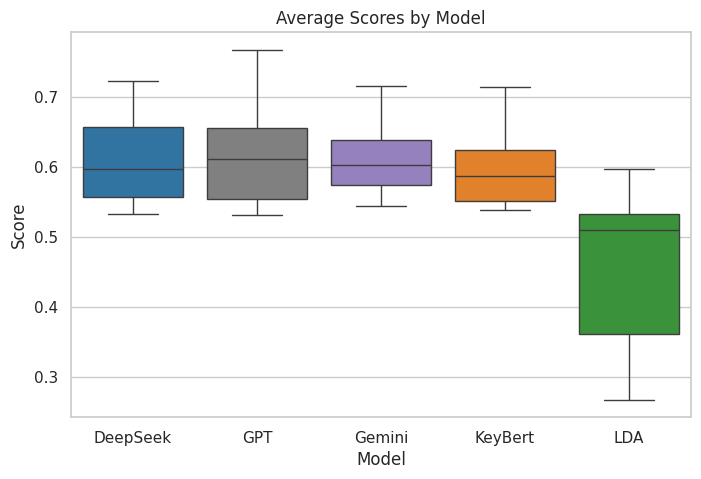

In [ ]:
# Define a color map for each model
color_map = {
    "GPT": "grey",       # ChatGPT color
    "DeepSeek": "#1f77b4", # DeepSeek color
    "Gemini": "#9177C7", # Gemini color
    "KeyBert": "#ff7f0e",  # Orange
    "LDA": "#2ca02c"       # Green
}

# Plotting the average scores for each model
plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")

# Create a boxplot to visualize score distribution per model with the custom color palette
sns.boxplot(data=average_scores_df, x="Model", y="average_score", palette=color_map)

# Adding a title and labels
plt.title("Average Scores by Model")
plt.xlabel("Model")
plt.ylabel("Score")

# Show the plot
plt.show()


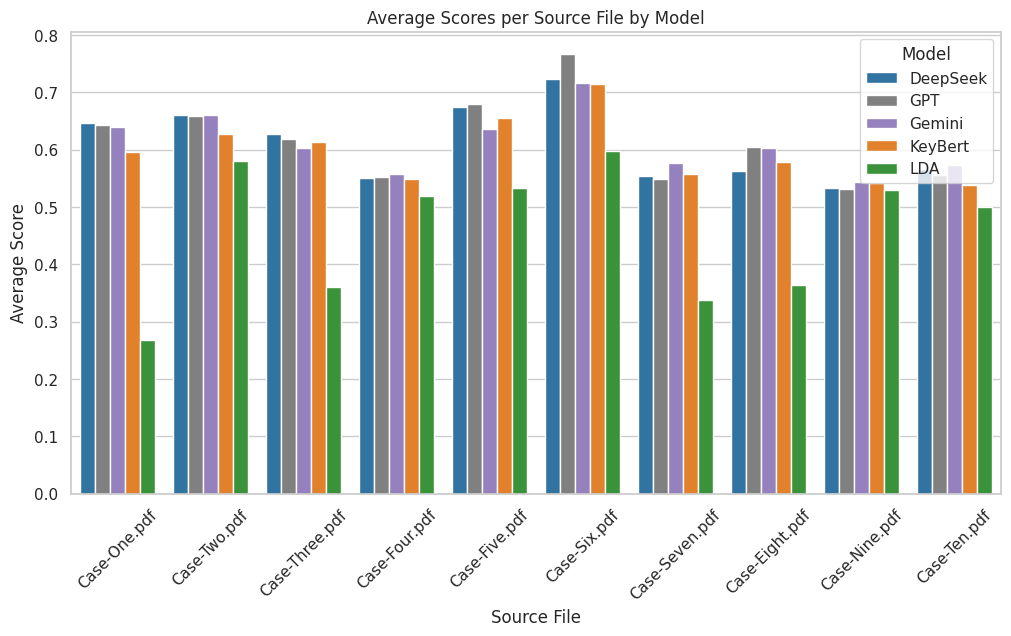

In [ ]:
# Define the correct order for source files
ordered_files = [f"Case-{word}.pdf" for word in [
    "One", "Two", "Three", "Four", "Five", "Six", "Seven", "Eight", "Nine", "Ten"
]]

# Set categorical type to enforce the desired order
average_scores_df['source_file'] = pd.Categorical(
    average_scores_df['source_file'], categories=ordered_files, ordered=True
)

# Group by source_file and model, calculate mean score
grouped_scores = average_scores_df.groupby(['source_file', 'Model'])['average_score'].mean().reset_index()

# Define a color map for each model
color_map = {
    "GPT": "grey",       # ChatGPT color
    "DeepSeek": "#1f77b4", # DeepSeek color
    "Gemini": "#9177C7", # Gemini color
    "KeyBert": "#ff7f0e",  # Orange
    "LDA": "#2ca02c"       # Green
}

# Map the colors to the models
palette = [color_map[model] for model in grouped_scores['Model'].unique()]

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Create a bar plot with the specified color palette
sns.barplot(data=grouped_scores, x="source_file", y="average_score", hue="Model", palette=palette)

# Adding a title and labels
plt.title("Average Scores per Source File by Model")
plt.xlabel("Source File")
plt.ylabel("Average Score")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability

# Display the plot
plt.show()

### 3.2  Implications

Results confirm that modern LLM pipelines deliver superior contextual matching, but lightweight models still provide value where compute or licensing is constrained. The absence of citation‑level metadata in our scoring remains a limitation, reinforcing the future‑scope need for verification layers and richer ranking heuristics.


## 4.0 Future Scope

Two near‑term upgrades will make the pipeline production‑ready. 1 - Verification layer — automatic DOI checks plus Crossref/PubMed look‑ups to block hallucinated citations and flag metadata mismatches (Ji et al., 2023). 2 - Retrieval‑augmented generation — tie LLM prompting to a vector database and fine‑tune GPT or DeepSeek with a “citation‑first” objective, a method proven to boost factual reliability (Lewis et al., 2020).
Four research extensions follow:
1. Meta‑heuristic weighting: learn optimal scores from richer metadata (citation count, publication date, journal impact, author h‑index).
2. Repository expansion: integrate PubMed, IEEE Xplore and SSRN for broader domain coverage.
3. Human‑in‑the‑loop labelling: domain experts grade outputs to create gold standards and cost–benefit data.
4. Larger, multilingual benchmarks: include legal filings, regulatory submissions and non‑English PDFs to stress‑test domain transfer.

Combined, these steps point toward a verification‑aware, metadata‑savvy citation assistant that delivers LLM speed without compromising the credibility standards of publishers, consultancies and R & D teams.



## 5.0 Conclusion

We present the first open benchmark for AI‑based citation generation on business‑style PDFs, testing two premium LLMs (GPT‑4.1‑mini, DeepSeek) against two free baselines (KeyBERT, LDA) under identical conditions. LLM pipelines deliver the strongest contextual relevance, while lighter models serve as offline fall‑backs. Yet every system still produces occasional hallucinated or weakly sourced references, making external validation essential before enterprise rollout.
The study has limits: ranking used semantic similarity only, the corpus covered just ten English briefs and scoring lacked expert review. These factors may restrict transferability to other domains or languages.
Our Future Scope roadmap—verification layers, multi‑repository search and human‑in‑the‑loop calibration—outlines how to turn this prototype into a compliance‑ready, credibility‑focused citation assistant trusted by publishers, consultancies and R & D teams.


## Bibliography


Bornmann, L. & Daniel, H.‑D. (2008) ‘What do citation counts measure? A review of studies on citing behavior’, Journal of Documentation, 64 (1), pp. 45–80.


Ji, Z., Lee, N., Frieske, R. et al. (2023) ‘Survey of hallucination in natural‑language generation’, ACM Computing Surveys, 55 (12), 248.


Lewis, P., Perez, E., Piktus, A. et al. (2020) ‘Retrieval‑augmented generation for knowledge‑intensive NLP tasks’, Advances in Neural Information Processing Systems 33, pp. 9459–9474.


Tennant, J.P., Dugan, J.M. & Bobe, J. (2024) ‘Artificial intelligence in scholarly communication: Opportunities, risks and future directions’, F1000Research, 12, 126. doi:10.12688/f1000research.139677.1.



Walters, W.H. & Wilder, E.I. (2023) ‘Fabrication and errors in the bibliographic citations generated by ChatGPT’, Scientific Reports, 13, 14045. doi:10.1038/s41598‑023‑41032‑5.
